
<h1 style="color:blue; text-align:center;">#RESOLVENDO CASE</h1>

DESCRIÇÃO DO CASE:

Uma loja de e-commerce precisa entender o comportamento de vendas dos últimos 2 anos para:

Identificar tendências sazonais

Otimizar campanhas de marketing

Melhorar gestão de estoque

Aumentar faturamento

In [43]:
# Importação da biblioteca para manipulação de dados em tabelas
import pandas as pd

# Importação da biblioteca NumPy para operações matemáticas e arrays
import numpy as np

# Importação da biblioteca Matplotlib para geração de gráficos
import matplotlib.pyplot as plt   

# Importação da biblioteca random para geração de números aleatórios
import random  

# Importação das classes datetime e timedelta para manipulação de datas e intervalos de tempo
from datetime import datetime, timedelta  

# Comando mágico do Jupyter Notebook que permite exibir gráficos diretamente no notebook
%matplotlib inline  

In [44]:

%reload_ext watermark
%watermark -a "InteliTech"

Author: InteliTech



## 3. Função Para Geração de Dados Fictícios

Excelente forma de praticar muito do que vimos até aqui neste capítulo.

In [45]:
# Definição da função para gerar dados fictícios de vendas
def dsa_gera_dados_ficticios(num_registros=800):
    print(f"\nIniciando a geração de {num_registros} registros de vendas...")

    # Dicionário CORRIGIDO
    produtos = {
        'Vestido': {'Categoria': 'Moda', 'Preco_Medio': 250.00, 'Variacao': 0.30, 'Estoque_Inicial': 30},
        'Notebook': {'Categoria': 'Eletronico', 'Preco_Medio': 3500.00, 'Variacao': 0.30, 'Estoque_Inicial': 50},
        'Tenis Casual': {'Categoria': 'Moda', 'Preco_Medio': 150.00, 'Variacao': 0.20, 'Estoque_Inicial': 30},
        'Shampoo + Condicionador': {'Categoria': 'Beleza', 'Preco_Medio': 100.00, 'Variacao': 0.30, 'Estoque_Inicial': 100},
        'Bermuda': {'Categoria': 'Moda', 'Preco_Medio': 100.00, 'Variacao': 0.15, 'Estoque_Inicial': 60},
        'Headset': {'Categoria': 'Eletronico', 'Preco_Medio': 400.00, 'Variacao': 0.30, 'Estoque_Inicial': 15},
        'Paleta de Sombra': {'Categoria': 'Beleza', 'Preco_Medio': 45.00, 'Variacao': 0.15, 'Estoque_Inicial': 100},
        'Mouse Gamer': {'Categoria': 'Eletronico', 'Preco_Medio': 250.00, 'Variacao': 0.20, 'Estoque_Inicial': 15},
        'Base liquida': {'Categoria': 'Beleza', 'Preco_Medio': 30.00, 'Variacao': 0.10, 'Estoque_Inicial': 150},
        'Teclado Mecanico': {'Categoria': 'Eletronico', 'Preco_Medio': 250.00, 'Variacao': 0.25, 'Estoque_Inicial': 50},
        'Saia': {'Categoria': 'Moda', 'Preco_Medio': 150.00, 'Variacao': 0.15, 'Estoque_Inicial': 30},
        'Po Compacto': {'Categoria': 'Beleza', 'Preco_Medio': 45.00, 'Variacao': 0.10, 'Estoque_Inicial': 50},
        'Sandalia': {'Categoria': 'Moda', 'Preco_Medio': 250.00, 'Variacao': 0.20, 'Estoque_Inicial': 70},
        'Monitor': {'Categoria': 'Eletronico', 'Preco_Medio': 550.00, 'Variacao': 0.25, 'Estoque_Inicial': 25},
        'Kit de Maquiagem': {'Categoria': 'Beleza', 'Preco_Medio': 600.00, 'Variacao': 0.25, 'Estoque_Inicial': 25}
    }
    
    lista_produtos = list(produtos.keys())
    
    cidades_estados = {
        'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS', 'Salvador': 'BA', 'Curitiba': 'PR', 'Fortaleza': 'CE'
    }
    
    lista_cidades = list(cidades_estados.keys())
    dados_vendas = []
    
    # Canais de venda
    canais_venda = ['Site', 'App Mobile', 'Marketplace']
    
    # Data inicial - 2 anos atrás
    data_inicio = datetime(2022, 1, 1)
    data_fim = datetime(2023, 12, 31)
    
    # Gera os registros de vendas
    for i in range(num_registros):
        # Seleciona um produto aleatório
        produto_nome = random.choice(lista_produtos)
        produto_info = produtos[produto_nome]
        
        # Gera data aleatória dentro do período
        dias_diff = (data_fim - data_inicio).days
        data_aleatoria = data_inicio + timedelta(days=random.randint(0, dias_diff))
        
        # Calcula preço com variação
        preco_medio = produto_info['Preco_Medio']
        variacao = produto_info['Variacao']
        preco_final = round(preco_medio * random.uniform(1 - variacao, 1 + variacao), 2)
        
        # Gera quantidade (mais vendas de 1 unidade, menos de múltiplas)
        quantidade = random.choices([1, 2, 3, 4, 5], weights=[0.6, 0.2, 0.1, 0.05, 0.05])[0]
        
        # Calcula valor total
        valor_total = round(preco_final * quantidade, 2)
        
        # Seleciona cidade e canal aleatórios
        cidade = random.choice(lista_cidades)
        canal = random.choice(canais_venda)
        
        # Cria o registro
        registro = {
            'data_pedido': data_aleatoria,
            'produto': produto_nome,
            'categoria': produto_info['Categoria'],
            'quantidade': quantidade,
            'valor_unitario': preco_final,
            'valor_total': valor_total,
            'cidade': cidade,
            'estado': cidades_estados[cidade],
            'canal_venda': canal
        }
        
        dados_vendas.append(registro)
    
    # Cria DataFrame
    df_vendas = pd.DataFrame(dados_vendas)
    
    # Ordena por data
    df_vendas = df_vendas.sort_values('data_pedido').reset_index(drop=True)
    
    print(f" Geração concluída! {len(df_vendas)} registros criados.")
    print(f" Período: {df_vendas['data_pedido'].min().strftime('%d/%m/%Y')} a {df_vendas['data_pedido'].max().strftime('%d/%m/%Y')}")
    print(f" Categorias: {df_vendas['categoria'].value_counts().to_dict()}")
    
    return df_vendas

In [46]:
  # Gera e exibe os dados
df_vendas = dsa_gera_dados_ficticios(1000)
print("\nPrimeiras linhas do dataset:")
print(df_vendas.head(10))


Iniciando a geração de 1000 registros de vendas...
 Geração concluída! 1000 registros criados.
 Período: 01/01/2022 a 31/12/2023
 Categorias: {'Moda': 337, 'Eletronico': 336, 'Beleza': 327}

Primeiras linhas do dataset:
  data_pedido           produto   categoria  quantidade  valor_unitario  \
0  2022-01-01  Paleta de Sombra      Beleza           1           48.12   
1  2022-01-01          Sandalia        Moda           4          227.18   
2  2022-01-01      Tenis Casual        Moda           1          153.26   
3  2022-01-04      Tenis Casual        Moda           1          139.38   
4  2022-01-06           Bermuda        Moda           3           89.81   
5  2022-01-06           Bermuda        Moda           1           93.19   
6  2022-01-06      Base liquida      Beleza           1           27.66   
7  2022-01-06           Monitor  Eletronico           3          447.50   
8  2022-01-07           Bermuda        Moda           3           97.73   
9  2022-01-07      Base liqui

-A partir das primeiras 10 linhas do meu dataset percebemos que nos mês de janeiro do ano de 2022, houve maior procura em quantidade por produtos de beleza, seguido por produtos eletrônicos no qual nos dar maior retorno financeiro mesmo em menor quantidade de pedidos.
-Analisando a quantidade de lucratividade por canal de vendas percebemos um maior índece pelo App Mobile, mas com maior índece de vendas pelo site. E sobre a lucratividade por cidades, percebemos que nossos maiores compradores estão localizados na cidade de Salvador, seguidos de Curitiba e Fortaleza, comprando em menor quantidade São Paulo e Belo Horizonte. Entretanto, Belo Horizonte apresentou o maior valor total de vendas, resultado de um pedido de alto valor unitário, o que elevou a lucratividade da região Sudeste no mês de janeiro de 2022.

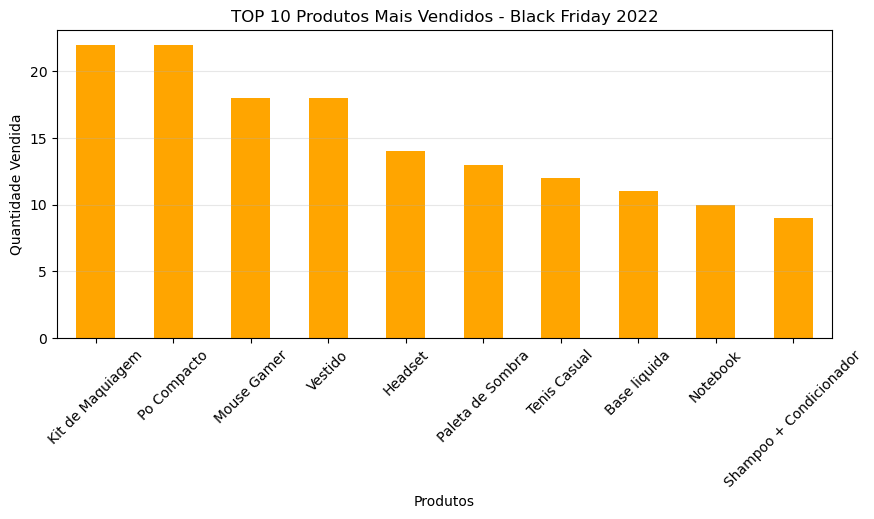

 Total de vendas na Black Friday: 185 unidades


In [47]:
# Filtrar dados de Novembro (Black Friday)
df_blackfriday = df_vendas[df_vendas['data_pedido'].dt.month == 11]

# Produtos mais vendidos na Black Friday
produtos_blackfriday = df_blackfriday.groupby('produto')['quantidade'].sum().sort_values(ascending=False)

# Gráfico de barras
plt.figure(figsize=(10, 4))
produtos_blackfriday.head(10).plot(kind='bar', color='orange')
plt.title('TOP 10 Produtos Mais Vendidos - Black Friday 2022')
plt.xlabel('Produtos')
plt.ylabel('Quantidade Vendida')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f" Total de vendas na Black Friday: {df_blackfriday['quantidade'].sum()} unidades")

-Pela a observação do gráfico de vendas na blackfriday de 2022, concluímos que os produtos das categorias eletrônicos e de moda lideraram os números de vendas, ocupando intercaladamente as 6 primeiras colocações de 10 produtos mais vendidos no período descrito, e não podemos ignorar o fato dos produtos eletrônicos se configurarem a categoria de produtos com maior preço e liderarem o número de procura e compra nesses períodos, enquanto os produtos de beleza que são produtos mais vendidos e consumidos no cotidiano, ficam em última instância.

C:\Users\Italo Lima\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127876 (\N{CHRISTMAS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


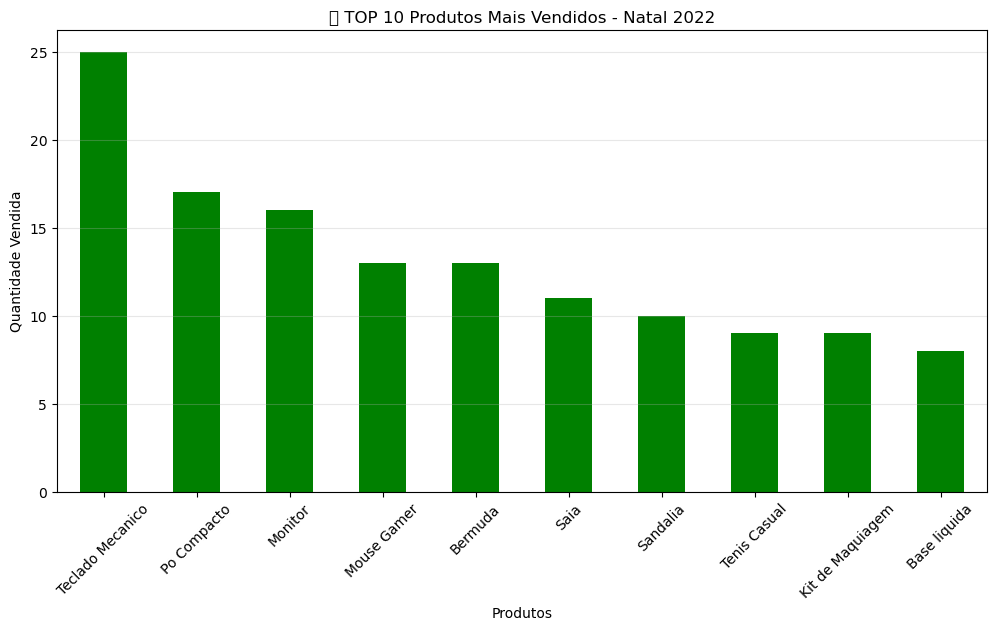

🎁 Total de vendas no Natal: 159 unidades


In [48]:
# Filtrar dados de Dezembro (Natal)
df_natal = df_vendas[df_vendas['data_pedido'].dt.month == 12]

# Produtos mais vendidos no Natal
produtos_natal = df_natal.groupby('produto')['quantidade'].sum().sort_values(ascending=False)

# Gráfico de barras
plt.figure(figsize=(12, 6))
produtos_natal.head(10).plot(kind='bar', color='green')
plt.title('🎄 TOP 10 Produtos Mais Vendidos - Natal 2022')
plt.xlabel('Produtos')
plt.ylabel('Quantidade Vendida')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"🎁 Total de vendas no Natal: {df_natal['quantidade'].sum()} unidades")

-Já no natal do mesmo ano, percebemos uma variedade nas compras das categorias e o aumento considerável nos produtos de beleza, seguido por produtos eletrônicos e de moda. Podemos, presumir que esses produtos são mais consumidos nessa época do ano devido terem aproveitado a blackfriday do período anterior(que geralmente ocorre no mês de novembro), para comprar os produtos que são mais caros no mercado, e passam a consumir mais produtos de beleza visto que nessa época do ano naturalmente se consume mais devido as festividades e confraternizações de fim de ano, mas ainda assim há um grande percentual de vendas de produtos eletrônicos que também costumam ser dados como presentes nessas comemorações, o que nos leva a concluir que vale investir e aumentar o estoque desses produtos para o mês de novembro e dezembro.

C:\Users\Italo Lima\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


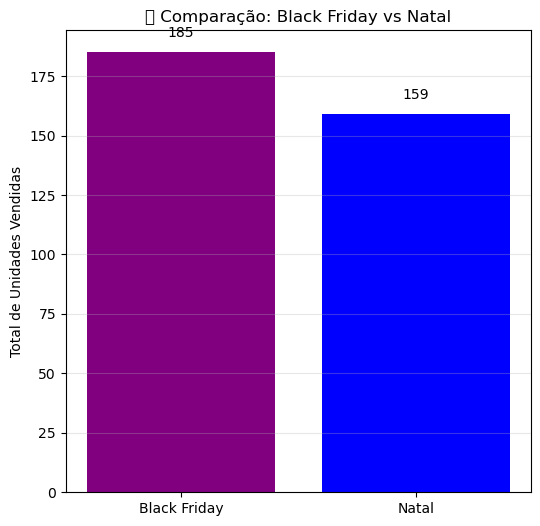

In [49]:
# Comparar Black Friday vs Natal
vendas_blackfriday = df_blackfriday['quantidade'].sum()
vendas_natal = df_natal['quantidade'].sum()

# Gráfico de comparação
periodos = ['Black Friday', 'Natal']
vendas = [vendas_blackfriday, vendas_natal]

plt.figure(figsize=(6, 6))
plt.bar(periodos, vendas, color=['purple', 'blue'])
plt.title('📊 Comparação: Black Friday vs Natal')
plt.ylabel('Total de Unidades Vendidas')
plt.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, v in enumerate(vendas):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')

plt.show()

-Percebemos pela observação do gráfico comparativo de vendas entre a black friday e o natal, que este segundo teve o maior índice de vendas mesmo a black friday representando um período de grandes ofertas promocionais, entretanto no período natalino também são ofertadas bastante valores promocionais e por ser uma data comemorativa representa uma das épocas em que as pessoas mais investem em presentes.

In [50]:
# Para ver vendas de Verão (Janeiro a Março)
df_verao = df_vendas[df_vendas['data_pedido'].dt.month.isin([1, 2, 3])]

# Para ver vendas de um produto específico no tempo
produto_especifico = df_vendas[df_vendas['produto'] == 'Notebook']

# Para ver vendas por canal na Black Friday
canal_bf = df_blackfriday.groupby('canal_venda')['quantidade'].sum()

df_verao.head()


,data_pedido,produto,categoria,quantidade,valor_unitario,valor_total,cidade,estado,canal_venda
0,2022-01-01,Paleta de Sombra,Beleza,1,48.12,48.12,Rio de Janeiro,RJ,Site
1,2022-01-01,Sandalia,Moda,4,227.18,908.72,Porto Alegre,RS,Marketplace
2,2022-01-01,Tenis Casual,Moda,1,153.26,153.26,Porto Alegre,RS,Marketplace
3,2022-01-04,Tenis Casual,Moda,1,139.38,139.38,Porto Alegre,RS,Site
4,2022-01-06,Bermuda,Moda,3,89.81,269.43,Salvador,BA,Site


In [51]:
produto_especifico.head()

,data_pedido,produto,categoria,quantidade,valor_unitario,valor_total,cidade,estado,canal_venda
15,2022-01-11,Notebook,Eletronico,1,4384.99,4384.99,São Paulo,SP,App Mobile
24,2022-01-23,Notebook,Eletronico,1,2936.06,2936.06,Fortaleza,CE,App Mobile
27,2022-01-24,Notebook,Eletronico,1,3293.10,3293.10,Belo Horizonte,MG,Site
28,2022-01-24,Notebook,Eletronico,1,4485.17,4485.17,Salvador,BA,App Mobile
34,2022-01-28,Notebook,Eletronico,2,2633.06,5266.12,Porto Alegre,RS,App Mobile


In [52]:
canal_bf.head()

canal_venda
App Mobile     64
Marketplace    70
Site           51
Name: quantidade, dtype: int64